# VGG16 fine-tuning for defect detection

This section builds a VGG16 model with ImageNet weights, lets you choose any valid input shape (HxWx3), and fine-tune only the last layers you specify.

Two variants are trained, one per input resolution:

- **HR** classifies high-resolution and super-resolved images.
- **LR** classifies low-resolution images at their native size, and provides the baseline of the defect detection pipeline.

A single classifier cannot serve both roles. It extracts `VGG_PATCH_SIZE` patches from whatever image it receives, so feeding it a 239x239 LR image after training on 478x478 frames halves the apparent object scale and shrinks the number of voting patches. That scale mismatch penalises the baseline for reasons unrelated to resolution. Training one classifier per resolution removes it.

Both variants share every hyperparameter and every image-level partition, so the only difference between them is the resolution of their input.

In [1]:
import os
import sys
import datetime

import numpy as np

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
from srlib.defect_detection.vgg16 import FineTunedVGG16
from srlib.dataset.loading import load_vgg16_dataset
from srlib.dataset.visualization import plot_classification_patches
from srlib.deep_learning.visualization import plot_vgg16_training_curves
from srlib.constants import (
    CLASS_LABELS_PATH,
    DL_RESULTS_DIR,
    HR_ROOT,
    LR_ROOT,
    TIMESTAMP_FORMAT,
    VGG16_FIT_PARAMS,
    VGG16_SETUP_PARAMS,
    VGG16_SOURCES,
    VGG_PATCH_SIZE,
    VGG_STRIDE,
)

In [2]:
# X -> image patches (model input)
# y -> class labels (target)
# Both variants derive from the same image-level partition, so the HR and LR
# test sets contain the very same images at two resolutions.
datasets = {}

for source in VGG16_SOURCES:
    datasets[source] = load_vgg16_dataset(
        HR_ROOT,
        LR_ROOT,
        CLASS_LABELS_PATH,
        source=source,
        patch_size=VGG_PATCH_SIZE,
        stride=VGG_STRIDE,
    )


 VGG16 dataset [HR] | patch 96, stride 48
  images    798 indexed -> 798 kept -> 574 train / 64 val / 160 test


  patches   46,494 train / 5,184 val / 12,960 test   of 96 x 96 x 3
  memory    6.66 GB
  range     X [0.0000, 1.0000]
  classes   {0: 32157, 1: 32481}
  done in 9.1s


 VGG16 dataset [LR] | patch 96, stride 48
  images    798 indexed -> 798 kept -> 574 train / 64 val / 160 test


  patches   9,184 train / 1,024 val / 2,560 test   of 96 x 96 x 3
  memory    1.32 GB
  range     X [0.0000, 1.0000]
  classes   {0: 6352, 1: 6416}
  done in 2.4s



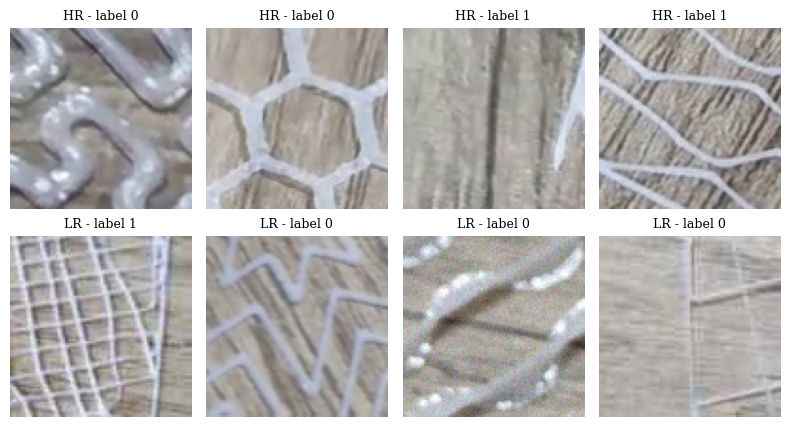

In [3]:
# Patches have the same pixel size in both rows, so the visible difference
# is the object scale each classifier learns to recognise.
_ = plot_classification_patches(
    {s: datasets[s][0] for s in VGG16_SOURCES},
    {s: datasets[s][1] for s in VGG16_SOURCES},
    count=4,
    seed=0,
)

In [4]:
models_by_source = {}

for source in VGG16_SOURCES:
    X_train, y_train = datasets[source][0], datasets[source][1]

    print(f"Building VGG16 for {source.upper()} patches")
    model = FineTunedVGG16()
    model.setup_model(
        input_shape=X_train.shape[1:],
        num_classes=np.unique(y_train).shape[0],
        **VGG16_SETUP_PARAMS,
    )

    models_by_source[source] = model

Building VGG16 for HR patches
Model: "vgg16_finetune"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         
                                                                 
 vgg16_preprocess (VGG16Prep  (None, 96, 96, 3)        0         
 rocessing)                                                      
                                                                 
 vgg16 (Functional)          (None, 3, 3, 512)         14714688  
                                                                 
 gap (GlobalAveragePooling2D  (None, 512)              0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)        

In [5]:
# Each entry holds the (head, fine-tuning) pair of histories, since the two
# phases are separate training runs with different learning rates.
histories_by_source = {}

for source in VGG16_SOURCES:
    X_train, y_train, X_val, y_val = datasets[source][:4]

    print(f"Training VGG16 on {source.upper()} patches")
    histories_by_source[source] = models_by_source[source].fit_two_phases(
        X_train, y_train,
        X_val, y_val,
        **VGG16_FIT_PARAMS,
    )

Training VGG16 on HR patches

Phase 1/2 - training the head only (131,842 trainable, 14,714,688 frozen)
Epoch 1/150
1453/1453 [==============================] - 58s 36ms/step - loss: 0.4063 - accuracy: 0.8671 - val_loss: 0.2442 - val_accuracy: 0.9142 - lr: 0.0010
Epoch 2/150
1453/1453 [==============================] - 52s 36ms/step - loss: 0.2682 - accuracy: 0.8979 - val_loss: 0.2137 - val_accuracy: 0.9236 - lr: 0.0010
Epoch 3/150
1453/1453 [==============================] - 52s 36ms/step - loss: 0.2558 - accuracy: 0.9033 - val_loss: 0.1965 - val_accuracy: 0.9358 - lr: 0.0010
Epoch 4/150
1453/1453 [==============================] - 53s 36ms/step - loss: 0.2483 - accuracy: 0.9073 - val_loss: 0.1939 - val_accuracy: 0.9333 - lr: 0.0010
Epoch 5/150
1453/1453 [==============================] - 52s 36ms/step - loss: 0.2449 - accuracy: 0.9094 - val_loss: 0.2028 - val_accuracy: 0.9317 - lr: 0.0010
Epoch 6/150
1453/1453 [==============================] - 52s 36ms/step - loss: 0.2416 - accuracy

In [6]:
# One timestamp for the whole run: both variants are told apart by their
# source tag, so model_registry resolves them as a single VGG16 run.
timestamp = datetime.datetime.now().strftime(TIMESTAMP_FORMAT)
metrics_by_source = {}

for source in VGG16_SOURCES:
    X_test, y_test = datasets[source][4], datasets[source][5]
    head_history, finetune_history = histories_by_source[source]

    _, _, metrics_by_source[source] = models_by_source[source].evaluate_and_save(
        X_test, y_test, head_history, finetune_history, source,
        timestamp=timestamp,
    )


 VGG16 [HR] run 20260914_235902
  evaluating on the test partition
405/405 [==============================] - 8s 19ms/step - loss: 0.0780 - accuracy: 0.9884
Loss: 0.0780, Accuracy: 0.9884
Model saved to c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\VGG16\VGG16_20260914_235902\VGG16_HR_20260914_235902\VGG16_HR_20260914_235902.h5
  metrics    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\VGG16\VGG16_20260914_235902\VGG16_HR_20260914_235902\VGG16_HR_20260914_235902_metrics.pkl
  summary    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\VGG16\VGG16_20260914_235902\VGG16_HR_20260914_235902\VGG16_HR_20260914_235902_summary.txt
  epochs     -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detectio

## Training curves

Both variants on the same axes, so the effect of the input resolution is visible directly. Training is solid, validation dashed, the dotted horizontal line is the test score and the dash-dotted vertical line marks the epoch the backbone was unfrozen, where a step in the curve is expected.

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='Epoch', ylabel='Loss'>,
        <Axes: title={'center': 'Accuracy'}, xlabel='Epoch', ylabel='Accuracy'>],
       dtype=object))

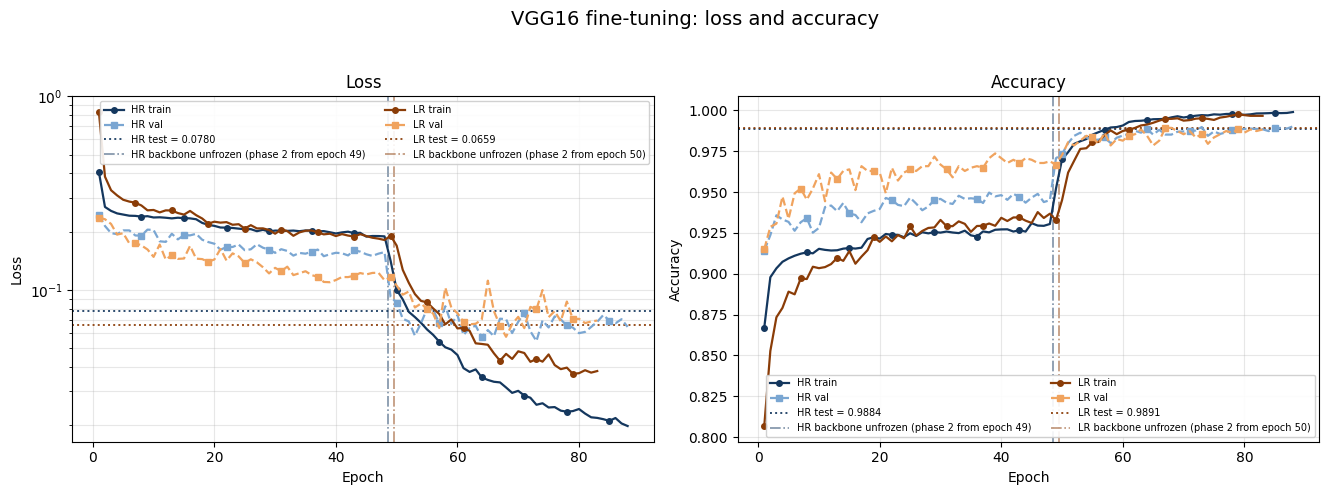

In [7]:
plot_vgg16_training_curves(metrics_by_source, save_path=DL_RESULTS_DIR)